In [1]:
import yaml
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pctk import multicellds

from cobra.io import read_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from cobra.flux_analysis.parsimonious import optimize_minimal_flux

In [2]:
init_concentration_default = 5.0
diffusion_coefficient_default = 50000.0
decay_rate_default = 0.0
Km_default = 0.001  # mM

cell_type = "MCF7_core"
cell_volume = 2494.0  # in um^3

sbml_file = "../config/MCF7_Zielinski_2017_core.sbml"
model = read_sbml_model(sbml_file, f_replace={'F_REACTION': lambda x: x})

for r in model.reactions:
    if r.objective_coefficient != 0:
        objective_reaction = r.id
        break
print(f"Objective reaction: {objective_reaction}")

solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Max growth rate: {max_growth_rate} 1/hr")

summary = model.summary()
print("Running FVA...")
fva_df = flux_variability_analysis(model, processes=10, fraction_of_optimum=0.0)


Objective reaction: R_biomass_reaction
Max growth rate: 0.026802255698138648 1/hr
Running FVA...


In [ ]:
fva_ex_df = fva_df.filter(regex='^R_EX', axis=0)

eps = 1e-7
mask = fva_ex_df.abs().max(axis=1) < eps
to_remove = fva_ex_df.index[mask]

Index(['R_EX_cl_e', 'R_EX_k_e', 'R_EX_na1_e'], dtype='object')

In [ ]:
to_remove = ["R_EX_cl_e", "R_EX_h_e", "R_EX_h2o_e", "R_EX_k_e", "R_EX_na1_e"]

fva_ex_df = fva_df.filter(regex='^R_EX', axis=0)
fva_ex_df = fva_ex_df.drop(to_remove, axis=0)

substrates_list = []
exchanges_list = []

for i in fva_ex_df.index:
    r = model.reactions.get_by_id(i)
    substrate = list(r.metabolites)[0].name

    Vmax = 0.0
    init_concentration = 0.0
    lb = fva_ex_df.loc[i, 'minimum'].round(5)
    if lb < 0.0:
        Vmax = -1.0 * float(lb)
        init_concentration = init_concentration_default

    substrates_dict = {
                        "name": substrate,
                        "diffusion_coefficient": diffusion_coefficient_default,   # or modify if needed
                        "decay_rate": decay_rate_default,
                        "initial_condition": init_concentration
                    }
    
    substrates_list.append(substrates_dict)
        
    exchange_dict = { 
        "substrate": substrate,
        "fba_flux": r.id,
        "Km": Km_default,
        "Vmax": float(Vmax)
    }

    exchanges_list.append( exchange_dict )


model_dict = {
    "settings": {
        "sbml_path": "config/MCF7_Zielinski_2017_core.sbml",
        "intracellular_dt": 0.01
    },
    "growth_model": {
            "cell_density": 1.04,              # Cell density (g/ml)
            "reference_volume": cell_volume,          # Reference volume for cell division (pg)
            "nuclear_volume": 540,            # Nuclear volume (pg)
            "max_growth_rate": max_growth_rate,           # Maximum growth rate (1/min)
            "objective_reaction": objective_reaction  # Objective reaction ID from SBML model
        },
    "death_model": {
            "enabled": False,
            "death_type": "necrosis",          # death type string
            "death_trigger_flux": 0.0,       # 1/min
            "death_flux_threshold": 0.0,     # dimensionless
            "death_rate_increase": 1.67e-5  # rate increase
    },
    "exchanges": exchanges_list
}

dfba_config_dict = {
    "substrates": substrates_list,
    "models": {
        cell_type: model_dict
    }
}

with open("../config/dfba_model.yaml", "w") as f:
    yaml.dump(dfba_config_dict, f, sort_keys=False, default_flow_style=False)

In [19]:
print("\n".join([i['name'] for i in substrates_list]))

L-Alanine
L-Arginine
L-Asparagine
L-Aspartate
Choline
Citrate
CO2
D-Glucose
L-Glutamine
L-Glutamate
Glycine
L-Isoleucine
L-Lactate
L-Leucine
L-Lysine
Ammonium
O2
Ornithine
L-Phenylalanine
Phosphate
L-Proline
L-Serine
L-Threonine
L-Tryptophan
L-Tyrosine
Urea
L-Valine
L-Malate


In [26]:
# --- Generate cell positions ---
cell_radius = (3.0 * cell_volume / (4.0 * math.pi)) ** (1.0 / 3.0)
sphere_radius = 12.5 * cell_radius
print(f"Cell radius: {cell_radius} um")
# --- lattice spacing (same as your C++ logic) ---
x_spacing = cell_radius * math.sqrt(3)
y_spacing = cell_radius * 2.0
z_spacing = cell_radius * math.sqrt(3)

rows = []
zc = 0
z = -sphere_radius
while z < sphere_radius:
    xc = 0
    x = -sphere_radius
    while x < sphere_radius:
        y = -sphere_radius
        while y < sphere_radius:

            px = x + (zc % 2) * 0.5 * cell_radius
            py = y + (xc % 2) * cell_radius
            pz = z

            if px*px + py*py + pz*pz < sphere_radius * sphere_radius:
                rows.append({
                    "x": px,
                    "y": py,
                    "z": pz,
                    "cell_type": cell_type,
                    "volume": np.random.uniform(cell_volume, cell_volume * 1.5)
                })

            y += y_spacing
        x += x_spacing
        xc += 1
    z += z_spacing
    zc += 1

df = pd.DataFrame(rows)
df.to_csv("../config/cells_large.csv", index=False)
print(df.shape)

Cell radius: 8.412710547954228 um
(1354, 5)


In [299]:
reactions = ["EX_glc_e", "EX_lac_L_e", "EX_o2_e", "EX_co2_e", "biomass_reaction"]
n = 100
m = len(reactions)
o2_lb = -2.5
model.reactions.EX_lac_L_e.lower_bound = 0.0
model.reactions.EX_lac_L_e.upper_bound = 1000.0
res1 = np.zeros((n,m))
bounds = np.linspace(-0.05, 0.0, n)
for i,lb in enumerate(bounds):
    model.reactions.EX_o2_e.lower_bound = lb
    s = model.optimize()
    if s.status == 'optimal':
        res1[i,:] = s.fluxes[reactions].values

df1 = pd.DataFrame(data=res1, index=bounds, columns=reactions)

model.reactions.EX_lac_L_e.lower_bound = 0.0
model.reactions.EX_lac_L_e.upper_bound = 0.0
res2 = np.zeros((n,5))
bounds = np.linspace(-0.5, 0.0, n)
for i,lb in enumerate(bounds):
    model.reactions.EX_o2_e.lower_bound = lb
    s = model.optimize()
    res2[i,0] = lb
    if s.status == 'optimal':
        res2[i,:] = s.fluxes[reactions].values

df2 = pd.DataFrame(data=res2, index=bounds, columns=reactions)

/home/mponce/projects/devel/PhysiCelldFBA/venv/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


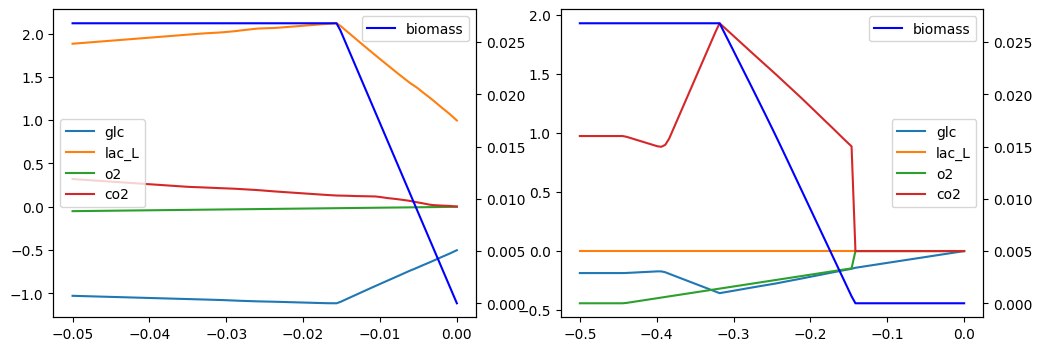

In [298]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

ax = axes[0]
#ax.set_ylim((-1.5, 5))
for i in reactions[:-1]:
    ax.plot(df1[i], label=i[3:-2])
ax.legend(loc=6)
ax = ax.twinx()
ax.plot(df1['biomass_reaction'], c='b', label='biomass')
ax.legend(loc=1)


ax = axes[1]
#ax.set_ylim((-1.5, 5))
for i in reactions[:-1]:
    ax.plot(df2[i], label=i[3:-2])
ax.legend(loc=5)
ax = ax.twinx()
ax.plot(df2['biomass_reaction'], c='b', label='biomass')
ax.legend(loc=1)

In [130]:
model.reactions.EX_o2_e.lower_bound = -0.25
model.optimize()


Metabolite,Reaction,Flux,C-Number,C-Flux
Tyr_ggn_c,DM_Tyr_ggn_c_,0.0009189,0,0.00%
gudac_c,DM_gudac_c_,0.009592,3,2.14%
arg_L_e,EX_arg_L_e,0.01014,6,4.53%
chol_e,EX_chol_e,0.0009479,5,0.35%
glc_D_e,EX_glc_e,0.05864,6,26.21%
gln_L_e,EX_gln_L_e,0.08788,5,32.73%
gly_e,EX_gly_e,0.001006,2,0.15%
h_e,EX_h_e,0.07246,0,0.00%
ile_L_e,EX_ile_L_e,0.008572,6,3.83%
leu_L_e,EX_leu_L_e,0.01471,6,6.57%


In [61]:
fva_df = flux_variability_analysis(model, processes=10, fraction_of_optimum=0.05)
fva_df

,minimum,maximum
DM_atp_c_,0.000000,53.536116
EX_ala_L_e,0.000000,0.008134
EX_arg_L_e,-0.010137,0.000000
EX_asn_L_e,-0.005834,0.000000
EX_asp_L_e,-0.009594,0.000000
...,...,...
DM_nadph[c],0.000000,12.646152
DM_nadph[m],0.000000,61.839501
DM_nadh_trans[m],0.000000,1000.000000
biomass_reaction,0.001340,0.026802


In [115]:
df = fva_df.filter(regex='^EX', axis=0)
df[df['maximum'] >= 0]

,minimum,maximum
EX_ala_L_e,0.000000,8.134442e-03
EX_arg_L_e,-0.010137,0.000000e+00
EX_asn_L_e,-0.005834,0.000000e+00
EX_asp_L_e,-0.009594,0.000000e+00
EX_cit_e,0.000000,2.172368e-03
EX_cl_e,0.000000,0.000000e+00
EX_co2_e,1.269914,3.725172e+01
EX_glu_L_e,-0.006695,0.000000e+00
EX_gly_e,-0.007382,0.000000e+00
EX_h_e,-0.259896,1.280150e+02


In [101]:
mcds_reader = multicellds.MultiCellDS("../output/")
col2idx = {n:i for i,n in enumerate(mcds_reader.cell_columns)}

columns = [
    "total_volume", "cell_dry_weight", "growth_rate", "R_biomass_reaction", 
    "oxygen_conc", "oxygen_total", "oxygen_NER", "R_EX_o2_e", 
    "glucose_conc", "glucose_total", "glucose_NER", "R_EX_glc_e", 
    "lactate_conc", "lactate_total", "lactate_NER", "R_EX_lac_D_e", 
    "co2_conc", "co2_total", "co2_NER", "R_EX_co2_e"
    ]

data = []
for t, a in mcds_reader.cells_as_matrix_iterator():
    if t == 0:
        continue
    
    row = [t]
    for c in columns:
        i = col2idx[c]
        value = a[0, i]
        row.append(value)
    data.append(row)

df = pd.DataFrame(data=data, columns=["time"] + columns)
df = df.set_index("time")
df

,total_volume,cell_dry_weight,growth_rate,R_biomass_reaction,oxygen_conc,oxygen_total,oxygen_NER,R_EX_o2_e,glucose_conc,glucose_total,glucose_NER,R_EX_glc_e,lactate_conc,lactate_total,lactate_NER,R_EX_lac_D_e,co2_conc,co2_total,co2_NER,R_EX_co2_e
time,,,,,,,,,,,,,,,,,,,,
1,2494.351029,785.720574,0.016889,-0.0,29.600587,9.990198e-11,-130659.588335,-9.977561,4.909739,1.657037e-11,-28976.974856,-2.212769,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.0


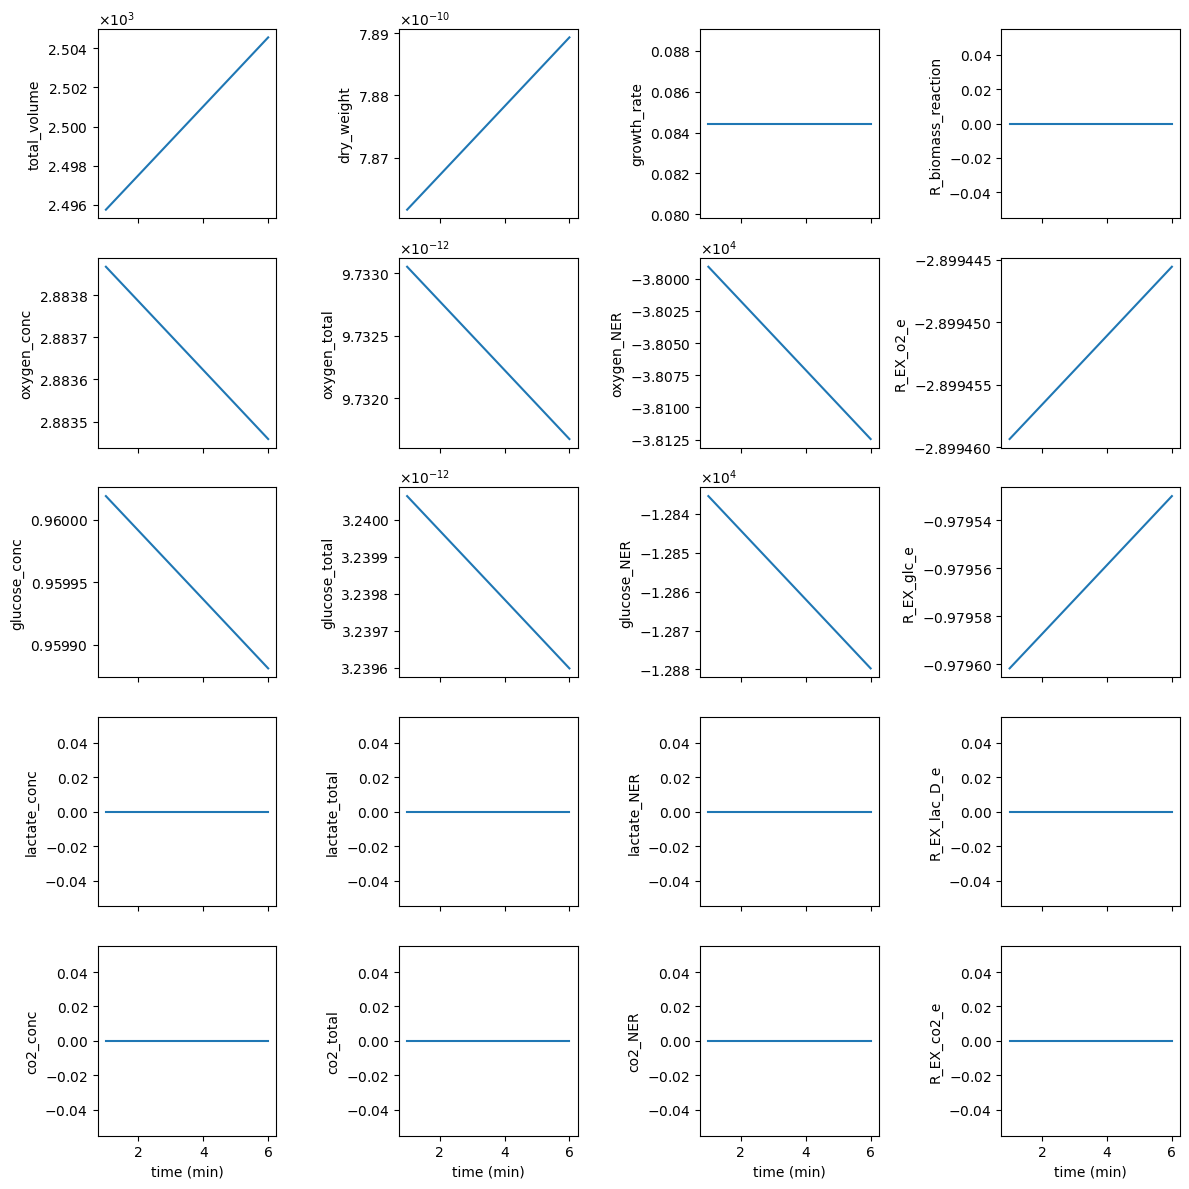

In [91]:
from matplotlib.ticker import ScalarFormatter
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(12, 12), sharex=True)

plots = [    
    ["total_volume", "dry_weight", "growth_rate", "R_biomass_reaction"],
    ["oxygen_conc", "oxygen_total", "oxygen_NER", "R_EX_o2_e"], 
    ["glucose_conc", "glucose_total", "glucose_NER", "R_EX_glc_e"], 
    ["lactate_conc", "lactate_total", "lactate_NER", "R_EX_lac_D_e"], 
    ["co2_conc", "co2_total", "co2_NER", "R_EX_co2_e"]
]

for row_idx, row in enumerate(plots):
    for col_idx, col in enumerate(row):

        ax = axes[row_idx, col_idx]
        ax.plot(df.index, df[col])
        ax.set_ylabel(col)

        # properly formatted scientific notation (no subtractions)
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True)
        fmt.set_powerlimits((-3, 3))
        fmt.set_useOffset(False)   # <<< absolutely critical
        ax.yaxis.set_major_formatter(fmt)

        if row_idx == len(plots) - 1:
            ax.set_xlabel("time (min)")

fig.tight_layout()